## Reconstructing spatially resolved star formation and chemical enrichment histories
Understanding how a galaxy was assembled over cosmic time requires analyzing the formation properties of its star particles on a pixel-by-pixel basis. The ``SFHReconstructor`` class in GalSyn provides a powerful tool to map the growth and chemical evolution across the entire region of galaxy. By binning star particles into discrete time intervals based on their formation lookback time, this module derives key milestones like cumulative mass assembly and mass-weighted metallicity histories for every spatial pixel. 

Below, is an example script for reconstructing spatially resolved SFH of a simulated galaxy.

In [ ]:
from galsyn.simutils_tng import get_snap_z
from galsyn import SFHReconstructor

# Your personal API key from the IllustrisTNG website
api_key = "your_api_key"

# Specify simulation parameters
sim = 'TNG50-1'         # The TNG simulation run
snap_number = 39        # The snapshot index (e.g., z ~ 1.5 in IllustrisTNG)
subhalo_id = 107965     # The subhalo ID

# Retrieve the exact redshift for the given snapshot number using the TNG API
z = get_snap_z(snap_number, api_key=api_key)
print ('Redshift: %lf' % z)

# Define the output path for the standardized file, generated using the script in Example 1
sim_file = f'sim_file_tng_{int(snap_number)}_{int(subhalo_id)}.hdf5'

# Initialize the Reconstructor
# Z_sun=0.019 is the default solar metallicity for FSPS/MIST
sfh = SFHReconstructor(sim_file, z, Z_sun=0.019)

sfh.dim_kpc = 90                # Spatial side length of the grid in kpc
sfh.pix_arcsec = 0.03           # Angular size of each pixel

sfh.polar_angle_deg = 0.0       # Polar angle or inclination
sfh.azimuth_angle_deg = 0.0     # azimuth angle or rotation in the xy-plane

sfh.ncpu = 5                    # Number of CPU cores for parallel processing
sfh.sfh_del_t = 0.05            # Lookback time bin width in Gyr

sfh.name_out_sfh = f"galsyn_sfh_{int(snap_number)}_{int(subhalo_id)}.fits"

# Execute the reconstruction
sfh.reconstruct_sfh()

Redshift: 1.531239
Processing sim_file_tng_39_107965.hdf5 at redshift z=1.53123902915761
Pixel size: 0.03 arcsec or 0.26 kpc
Cutout size: 346 x 346 pix or 90.00 x 90.00 kpc

Starting parallel SFH reconstruction on 5 cores...


Processing pixels for SFH:   0%|          | 0/119716 [00:00<?, ?it/s]


Finished parallel SFH reconstruction.
All SFH calculations complete. Maps populated.
Spatially resolved SFH reconstruction completed successfully and results saved to FITS file: galsyn_sfh_39_107965.fits


### Check the resulting data cube
In the following script, we plot star formation and chemical eenrichment histories of spatial regions within central 3 kpc radius and the disk (3-15 kpc). 

/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_73287/2985942829.py:35: RuntimeWarning: invalid value encountered in divide
  weighted_met = np.nansum(met_cube[:, mask] * mass_cube[:, mask], axis=1) / np.sum(mass_cube[:, mask], axis=1)


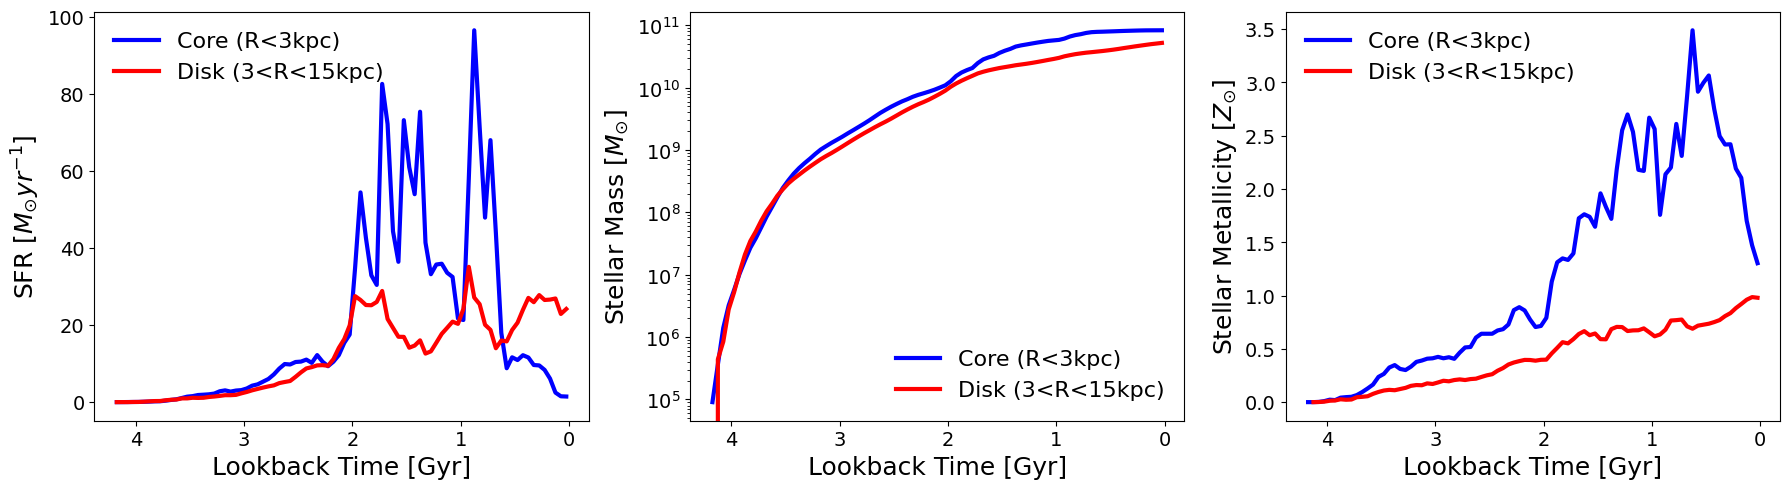

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Load Data
filename = f"galsyn_sfh_{int(snap_number)}_{int(subhalo_id)}.fits"

with fits.open(filename) as hdul:
    # Transpose 3D cubes to (time, y, x) and extract scalars
    sfr_cube = np.transpose(hdul['SFR'].data, (2, 0, 1))
    mass_cube = np.transpose(hdul['MASS'].data, (2, 0, 1))
    cumul_cube = np.transpose(hdul['CUMUL_MASS'].data, (2, 0, 1))
    met_cube = np.transpose(hdul['METALLICITY'].data, (2, 0, 1))
    
    t_maps = [hdul[f'T_{p}_PERCENT'].data for p in [5, 10, 25, 50, 75, 95]]
    lookback_time = hdul['LOOKBACK_TIME_BINS'].data
    pix_kpc = hdul[0].header['PIX_KPC']

# Create Spatial Masks
ny, nx = sfr_cube.shape[1:]
y, x = np.ogrid[:ny, :nx]
r_kpc = np.sqrt((x - nx//2)**2 + (y - ny//2)**2) * pix_kpc

inner_m = r_kpc <= 3.0
disk_m = (r_kpc > 3.0) & (r_kpc <= 15.0)

# Vectorized Integration & Mass-Weighted Metallicity
def get_stats(mask):
    # Sum over spatial axes (1, 2)
    sfr = np.sum(sfr_cube[:, mask], axis=1)
    cumul = np.sum(cumul_cube[:, mask], axis=1)
    
    # Mass-weighted metallicity: sum(Z * M) / sum(M) per time slice
    # Use nanamm to handle potential NaNs in metallicity
    weighted_met = np.nansum(met_cube[:, mask] * mass_cube[:, mask], axis=1) / np.sum(mass_cube[:, mask], axis=1)
    return sfr, cumul, weighted_met

sfr_i, cumul_i, met_i = get_stats(inner_m)
sfr_d, cumul_d, met_d = get_stats(disk_m)

# Plotting SFH, Mass, Metallicity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plotting config (shared across panels)
line_cfg = {'inner': {'color': 'b', 'lw': 3, 'label': 'Core (R<3kpc)'},
            'disk':  {'color': 'r', 'lw': 3, 'label': 'Disk (3<R<15kpc)'}}

for ax, data_i, data_d, ylabel, is_log in zip(axes, 
    [sfr_i, cumul_i, met_i], [sfr_d, cumul_d, met_d],
    ['SFR [$M_{\odot} yr^{-1}$]', 'Stellar Mass [$M_{\odot}$]', 'Stellar Metallicity [$Z_{\odot}$]'],
    [False, True, False]):
    
    ax.plot(lookback_time, data_i, **line_cfg['inner'])
    ax.plot(lookback_time, data_d, **line_cfg['disk'])
    ax.set_xlabel('Lookback Time [Gyr]', fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    plt.setp(ax.get_yticklabels(), fontsize=14)
    plt.setp(ax.get_xticklabels(), fontsize=14)
    ax.invert_xaxis()
    if is_log: ax.set_yscale('log')

    ax.legend(frameon=False, fontsize=16)

plt.tight_layout()
plt.show()